In [1]:
!pip install requests pandas scikit-learn joblib matplotlib seaborn

In [2]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score

In [3]:
CITIES = {
    "Karachi":    {"lat": 24.86, "lon": 67.01, "country": "PK", "rain_sensitivity": 0.95, "population_density": 0.95},
    "Lahore":     {"lat": 31.55, "lon": 74.35, "country": "PK", "rain_sensitivity": 0.80, "population_density": 0.85},
    "Islamabad":  {"lat": 33.72, "lon": 73.06, "country": "PK", "rain_sensitivity": 0.75, "population_density": 0.60},
    "London":     {"lat": 51.51, "lon": -0.13, "country": "GB", "rain_sensitivity": 0.35, "population_density": 0.80},
    "Manchester": {"lat": 53.48, "lon": -2.24, "country": "GB", "rain_sensitivity": 0.30, "population_density": 0.70},
    "New York":   {"lat": 40.71, "lon": -74.01,"country": "US", "rain_sensitivity": 0.45, "population_density": 0.90},
    "Chicago":    {"lat": 41.88, "lon": -87.63,"country": "US", "rain_sensitivity": 0.50, "population_density": 0.75},
    "Colombo":    {"lat": 6.93,  "lon": 79.85, "country": "LK", "rain_sensitivity": 0.40, "population_density": 0.65},
    "Kandy":      {"lat": 7.29,  "lon": 80.63, "country": "LK", "rain_sensitivity": 0.45, "population_density": 0.50},
}

In [10]:
from datetime import datetime, timedelta

def fetch_historical_weather(city_name, city_info, start_date="2021-01-01", end_date=None):
    # If end_date is not provided, set it to yesterday's date
    if end_date is None:
        end_date = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d")

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   city_info["lat"],
        "longitude":  city_info["lon"],
        "start_date": start_date,
        "end_date":   end_date,
        "hourly": (
            "temperature_2m,precipitation,windspeed_10m,"
            "visibility,relativehumidity_2m,"
            "cloudcover,snowfall,apparent_temperature"
        ),
        "timezone": "auto"
    }

    response = requests.get(url, params=params)
    data = response.json()

    # Add error checking for API response
    if response.status_code != 200 or "hourly" not in data:
        print(f"Error fetching data for {city_name}. Status Code: {response.status_code}")
        print(f"API Response: {data}")
        # Return an empty DataFrame to avoid KeyErrors and allow concatenation to proceed
        return pd.DataFrame()

    df = pd.DataFrame({
        "datetime":             pd.to_datetime(data["hourly"]["time"]),
        "temperature":          data["hourly"]["temperature_2m"],
        "apparent_temperature": data["hourly"]["apparent_temperature"],
        "rainfall":             data["hourly"]["precipitation"],
        "windspeed":            data["hourly"]["windspeed_10m"],
        "visibility":           data["hourly"]["visibility"],
        "humidity":             data["hourly"]["relativehumidity_2m"],
        "cloudcover":           data["hourly"]["cloudcover"],
        "snowfall":             data["hourly"]["snowfall"],
    })

    df["city"]               = city_name
    df["country"]            = city_info["country"]
    df["rain_sensitivity"]   = city_info["rain_sensitivity"]
    df["population_density"] = city_info["population_density"]
    return df


all_dfs = []
for city, info in CITIES.items():
    print(f"Fetching {city}...")
    df = fetch_historical_weather(city, info)
    if not df.empty:
        all_dfs.append(df)
    time.sleep(1.5) # Increased sleep to avoid API rate limits

# Check if all_dfs is not empty before concatenating
if all_dfs:
    # Address FutureWarning by not using inplace=True and using infer_objects
    raw_df = pd.concat(all_dfs, ignore_index=True).fillna(0).infer_objects(copy=False)
    print(f"\nTotal rows: {len(raw_df):,}")
    print(raw_df.head())
else:
    print("\nNo data was fetched for any city.")
    raw_df = pd.DataFrame() # Define raw_df as an empty DataFrame to prevent NameError in subsequent cells

Fetching Karachi...
Fetching Lahore...
Fetching Islamabad...
Fetching London...
Fetching Manchester...
Fetching New York...
Fetching Chicago...
Error fetching data for Chicago. Status Code: 429
API Response: {'error': True, 'reason': 'Minutely API request limit exceeded. Please try again in one minute.'}
Fetching Colombo...
Error fetching data for Colombo. Status Code: 429
API Response: {'reason': 'Minutely API request limit exceeded. Please try again in one minute.', 'error': True}
Fetching Kandy...
Error fetching data for Kandy. Status Code: 429
API Response: {'reason': 'Minutely API request limit exceeded. Please try again in one minute.', 'error': True}

Total rows: 277,344
             datetime  temperature  apparent_temperature  rainfall  windspeed  \
0 2021-01-01 00:00:00         13.6                   9.7       0.0       14.4   
1 2021-01-01 01:00:00         13.1                   9.1       0.0       15.0   
2 2021-01-01 02:00:00         12.6                   8.4       0.0    

/tmp/ipykernel_4220/2295392087.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  raw_df = pd.concat(all_dfs, ignore_index=True).fillna(0).infer_objects(copy=False)


In [11]:
def engineer_features(df):
    df = df.copy()

    # Time features
    df["hour"]         = df["datetime"].dt.hour
    df["day_of_week"]  = df["datetime"].dt.dayofweek
    df["month"]        = df["datetime"].dt.month
    df["is_rush_hour"] = df["hour"].apply(
        lambda h: 1 if h in range(7, 10) or h in range(17, 20) else 0
    )
    df["is_weekend"]   = df["day_of_week"].apply(lambda d: 1 if d >= 5 else 0)
    df["is_night"]     = df["hour"].apply(lambda h: 1 if h < 6 or h >= 22 else 0)
    df["is_peak_evening"] = df["hour"].apply(lambda h: 1 if 18 <= h <= 22 else 0)

    # Season (based on month)
    def get_season(month):
        if month in [12, 1, 2]:  return 0  # winter
        elif month in [3, 4, 5]: return 1  # spring
        elif month in [6, 7, 8]: return 2  # summer
        else:                     return 3  # autumn
    df["season"] = df["month"].apply(get_season)

    # Encode city and country
    city_enc    = LabelEncoder()
    country_enc = LabelEncoder()
    df["city_encoded"]    = city_enc.fit_transform(df["city"])
    df["country_encoded"] = country_enc.fit_transform(df["country"])

    return df, city_enc, country_enc


df, city_enc, country_enc = engineer_features(raw_df)
print("Features engineered.")
print(df.columns.tolist())

Features engineered.
['datetime', 'temperature', 'apparent_temperature', 'rainfall', 'windspeed', 'visibility', 'humidity', 'cloudcover', 'snowfall', 'city', 'country', 'rain_sensitivity', 'population_density', 'hour', 'day_of_week', 'month', 'is_rush_hour', 'is_weekend', 'is_night', 'is_peak_evening', 'season', 'city_encoded', 'country_encoded']


In [12]:
def generate_traffic_label(row):
    score = 0

    # Rain × city sensitivity
    score += row["rainfall"] * row["rain_sensitivity"] * 3

    # Wind
    if row["windspeed"] > 50:   score += 2
    elif row["windspeed"] > 30: score += 1

    # Visibility
    if row["visibility"] < 1000:  score += 3
    elif row["visibility"] < 5000: score += 1

    # Snowfall
    if row["snowfall"] > 0: score += 2

    # Rush hour
    if row["is_rush_hour"]: score *= 1.5

    # Weekend discount
    if row["is_weekend"]: score *= 0.6

    # Night discount
    if row["is_night"]: score *= 0.4

    # Extreme temperature
    if row["temperature"] > 42 or row["temperature"] < -5: score += 1

    # Population density amplifies everything
    score *= (0.5 + row["population_density"] * 0.5)

    if score >= 5:   return "HIGH"
    elif score >= 2: return "MEDIUM"
    return "LOW"


df["traffic_label"] = df.apply(generate_traffic_label, axis=1)
print(df["traffic_label"].value_counts())

traffic_label
MEDIUM    151261
LOW       120904
HIGH        5179
Name: count, dtype: int64


In [13]:
def generate_energy_label(row):
    demand = 0

    # Temperature — apparent feels more realistic than raw temp
    t = row["apparent_temperature"]
    if t > 38:    demand += 40
    elif t > 32:  demand += 28
    elif t > 28:  demand += 18
    elif t < -5:  demand += 38
    elif t < 5:   demand += 28
    elif t < 12:  demand += 14

    # Humidity amplifies AC load
    if row["humidity"] > 80 and t > 25: demand += 8
    elif row["humidity"] > 65 and t > 25: demand += 4

    # Wind affects heating/cooling
    if row["windspeed"] > 50: demand += 6
    elif row["windspeed"] > 30: demand += 3

    # Cloud cover reduces solar → more grid load
    if row["cloudcover"] > 80: demand += 4

    # Snowfall → heating surge
    if row["snowfall"] > 0: demand += 10

    # Peak evening hours
    if row["is_peak_evening"]: demand *= 1.2

    # Night → lower baseline
    if row["is_night"]: demand *= 0.7

    # Population density scales demand
    demand *= (0.4 + row["population_density"] * 0.6)

    if demand >= 35:   return "HIGH"
    elif demand >= 15: return "MEDIUM"
    return "LOW"


def generate_energy_demand_pct(row):
    """Regression target — continuous % change in demand."""
    demand = 0
    t = row["apparent_temperature"]
    if t > 38:    demand += 40
    elif t > 32:  demand += 28
    elif t > 28:  demand += 18
    elif t < -5:  demand += 38
    elif t < 5:   demand += 28
    elif t < 12:  demand += 14
    if row["humidity"] > 80 and t > 25: demand += 8
    if row["windspeed"] > 50: demand += 6
    if row["snowfall"] > 0:   demand += 10
    if row["is_peak_evening"]: demand *= 1.2
    if row["is_night"]:        demand *= 0.7
    demand *= (0.4 + row["population_density"] * 0.6)
    return round(demand, 2)


df["energy_label"]      = df.apply(generate_energy_label, axis=1)
df["energy_demand_pct"] = df.apply(generate_energy_demand_pct, axis=1)
print(df["energy_label"].value_counts())
print(f"\nEnergy demand % range: {df['energy_demand_pct'].min():.1f} – {df['energy_demand_pct'].max():.1f}")

energy_label
LOW       151258
MEDIUM    111824
HIGH       14262
Name: count, dtype: int64

Energy demand % range: 0.0 – 55.9


In [14]:
def generate_retail_label(row):
    score = 0

    # Rain drives umbrella/raincoat demand
    if row["rainfall"] > 15:  score += 4
    elif row["rainfall"] > 5: score += 2
    elif row["rainfall"] > 1: score += 1

    # Extreme heat drives cold drinks, fans, sunscreen
    t = row["temperature"]
    if t > 38:    score += 4
    elif t > 30:  score += 2

    # Cold drives heaters, blankets, hot drinks
    if t < 0:     score += 4
    elif t < 10:  score += 2

    # Strong winds/storms drive emergency supplies
    if row["windspeed"] > 60: score += 3
    elif row["windspeed"] > 40: score += 1

    # Snowfall drives snow gear
    if row["snowfall"] > 5:   score += 3
    elif row["snowfall"] > 0: score += 1

    # Cloud cover — overcast days reduce foot traffic
    if row["cloudcover"] > 85: score += 1

    # Weekend boosts retail activity
    if row["is_weekend"]: score *= 1.2

    # Night reduces retail
    if row["is_night"]: score *= 0.3

    # Population density scales retail impact
    score *= (0.5 + row["population_density"] * 0.5)

    if score >= 4:   return "HIGH"
    elif score >= 2: return "MEDIUM"
    return "LOW"


df["retail_label"] = df.apply(generate_retail_label, axis=1)
print(df["retail_label"].value_counts())

retail_label
LOW       237654
MEDIUM     35845
HIGH        3845
Name: count, dtype: int64


In [15]:
FEATURES = [
    "temperature", "apparent_temperature", "rainfall", "windspeed",
    "visibility", "humidity", "cloudcover", "snowfall",
    "hour", "day_of_week", "month", "season",
    "is_rush_hour", "is_weekend", "is_night", "is_peak_evening",
    "city_encoded", "country_encoded",
    "rain_sensitivity", "population_density"
]

X = df[FEATURES]
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (277344, 20)


In [16]:
y_traffic = df["traffic_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_traffic, test_size=0.2, random_state=42, stratify=y_traffic
)

traffic_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=14,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
traffic_model.fit(X_train, y_train)

print("=== TRAFFIC MODEL ===")
print(f"Train accuracy: {traffic_model.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {traffic_model.score(X_test, y_test):.3f}")
print(classification_report(y_test, traffic_model.predict(X_test)))

=== TRAFFIC MODEL ===
Train accuracy: 0.998
Test accuracy:  0.997
              precision    recall  f1-score   support

        HIGH       0.90      1.00      0.94      1036
         LOW       1.00      1.00      1.00     24181
      MEDIUM       1.00      1.00      1.00     30252

    accuracy                           1.00     55469
   macro avg       0.97      1.00      0.98     55469
weighted avg       1.00      1.00      1.00     55469



In [17]:
y_energy = df["energy_label"]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X, y_energy, test_size=0.2, random_state=42, stratify=y_energy
)

energy_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=14,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
energy_model.fit(X_train_e, y_train_e)

print("=== ENERGY CLASSIFICATION MODEL ===")
print(f"Train accuracy: {energy_model.score(X_train_e, y_train_e):.3f}")
print(f"Test accuracy:  {energy_model.score(X_test_e, y_test_e):.3f}")
print(classification_report(y_test_e, energy_model.predict(X_test_e)))

=== ENERGY CLASSIFICATION MODEL ===
Train accuracy: 1.000
Test accuracy:  0.999
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00      2852
         LOW       1.00      1.00      1.00     30252
      MEDIUM       1.00      1.00      1.00     22365

    accuracy                           1.00     55469
   macro avg       1.00      1.00      1.00     55469
weighted avg       1.00      1.00      1.00     55469



In [18]:
y_demand = df["energy_demand_pct"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_demand, test_size=0.2, random_state=42
)

energy_regressor = RandomForestRegressor(
    n_estimators=150,
    max_depth=14,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
energy_regressor.fit(X_train_r, y_train_r)

y_pred_r = energy_regressor.predict(X_test_r)
print("=== ENERGY REGRESSION MODEL ===")
print(f"MAE : {mean_absolute_error(y_test_r, y_pred_r):.2f}%")
print(f"R²  : {r2_score(y_test_r, y_pred_r):.3f}")

=== ENERGY REGRESSION MODEL ===
MAE : 0.00%
R²  : 1.000


In [19]:
y_retail = df["retail_label"]

X_train_rt, X_test_rt, y_train_rt, y_test_rt = train_test_split(
    X, y_retail, test_size=0.2, random_state=42, stratify=y_retail
)

retail_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=14,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
retail_model.fit(X_train_rt, y_train_rt)

print("=== RETAIL MODEL ===")
print(f"Train accuracy: {retail_model.score(X_train_rt, y_train_rt):.3f}")
print(f"Test accuracy:  {retail_model.score(X_test_rt, y_test_rt):.3f}")
print(classification_report(y_test_rt, retail_model.predict(X_test_rt)))

=== RETAIL MODEL ===
Train accuracy: 1.000
Test accuracy:  1.000
              precision    recall  f1-score   support

        HIGH       1.00      0.98      0.99       769
         LOW       1.00      1.00      1.00     47531
      MEDIUM       1.00      1.00      1.00      7169

    accuracy                           1.00     55469
   macro avg       1.00      0.99      1.00     55469
weighted avg       1.00      1.00      1.00     55469



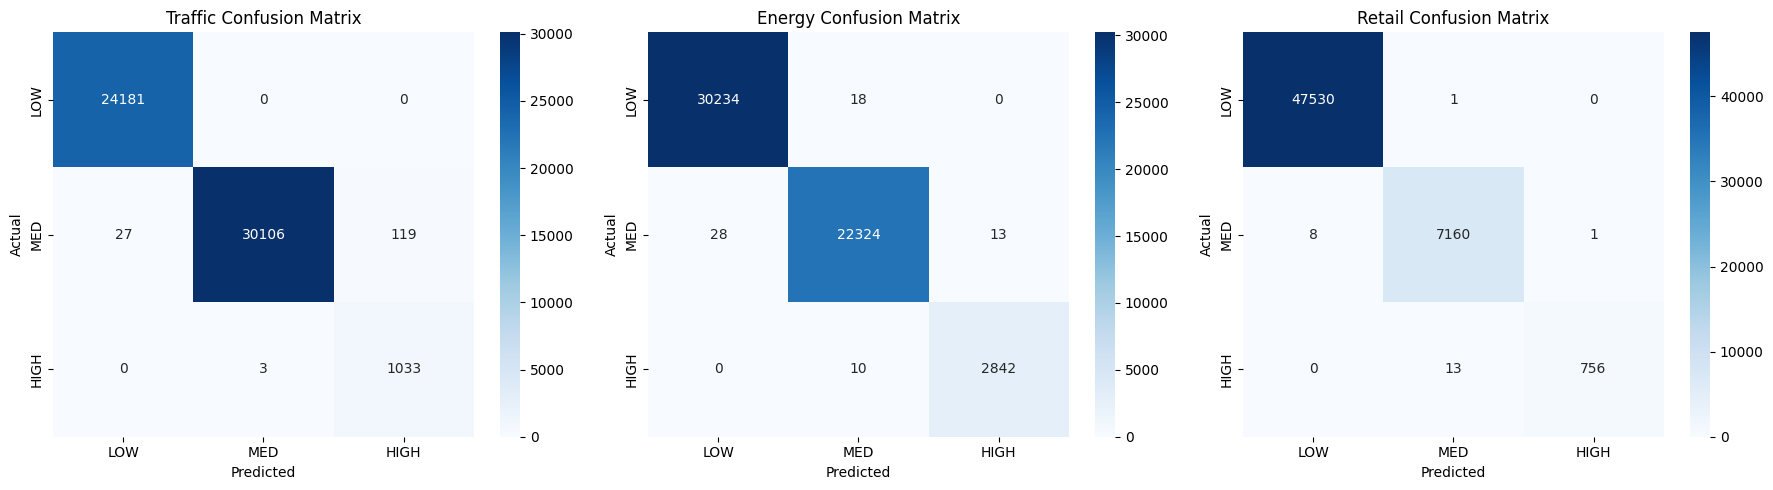

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (traffic_model, X_test,    y_test,    "Traffic"),
    (energy_model,  X_test_e,  y_test_e,  "Energy"),
    (retail_model,  X_test_rt, y_test_rt, "Retail"),
]

for ax, (model, Xt, yt, title) in zip(axes, models):
    cm = confusion_matrix(yt, model.predict(Xt), labels=["LOW","MEDIUM","HIGH"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["LOW","MED","HIGH"],
                yticklabels=["LOW","MED","HIGH"])
    ax.set_title(f"{title} Confusion Matrix")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

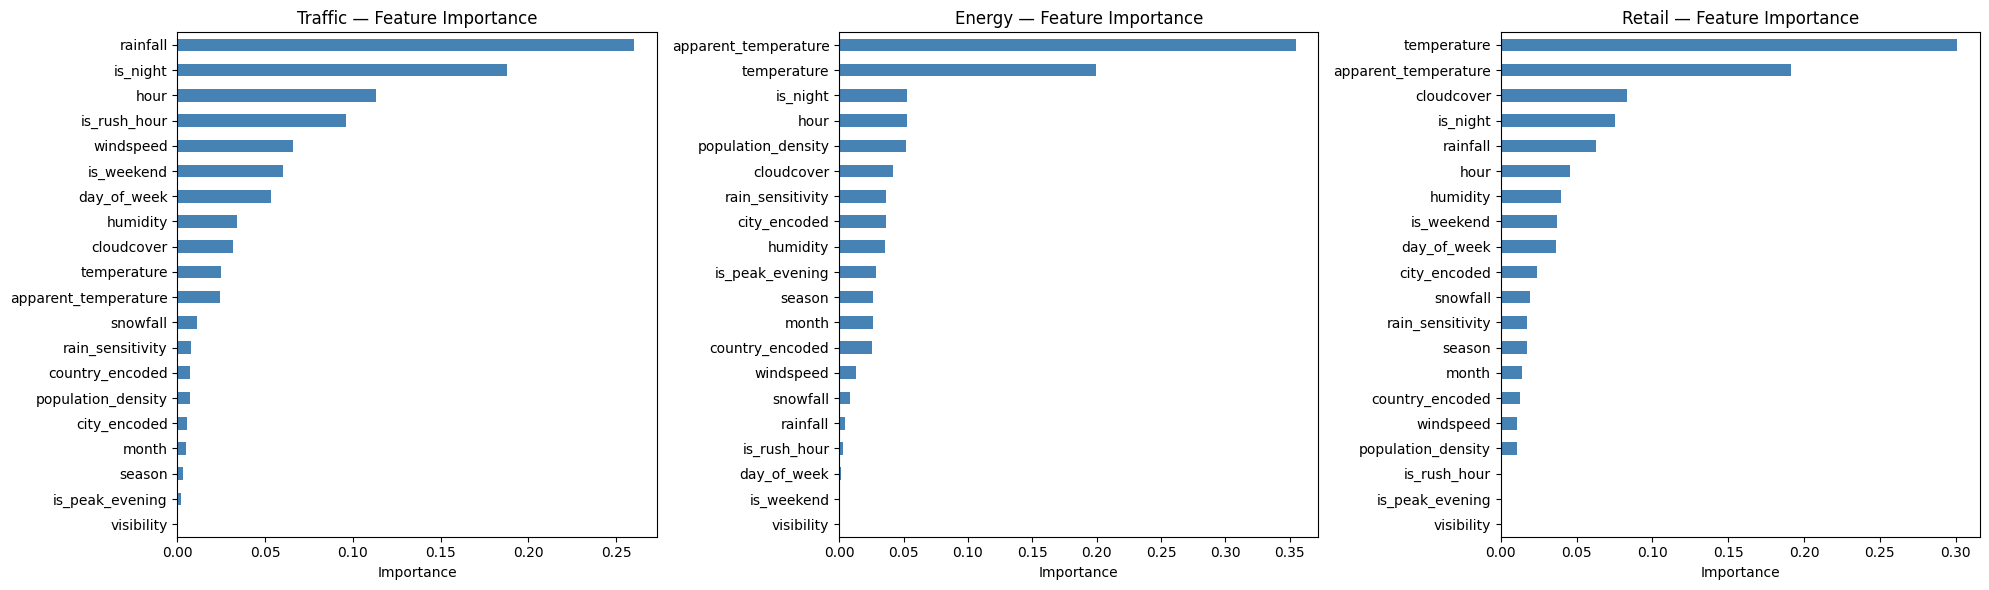

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model, title) in zip(axes, [
    (traffic_model, "Traffic"),
    (energy_model,  "Energy"),
    (retail_model,  "Retail"),
]):
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{title} — Feature Importance")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [21]:
joblib.dump(traffic_model,   "weather_traffic_model.pkl")
joblib.dump(energy_model,    "weather_energy_model.pkl")
joblib.dump(energy_regressor,"weather_energy_regressor.pkl")
joblib.dump(retail_model,    "weather_retail_model.pkl")
joblib.dump(city_enc,        "city_encoder.pkl")
joblib.dump(country_enc,     "country_encoder.pkl")
joblib.dump(FEATURES,        "feature_list.pkl")

print("All models saved:")
print("  weather_traffic_model.pkl")
print("  weather_energy_model.pkl")
print("  weather_energy_regressor.pkl")
print("  weather_retail_model.pkl")
print("  city_encoder.pkl")
print("  country_encoder.pkl")
print("  feature_list.pkl")

All models saved:
  weather_traffic_model.pkl
  weather_energy_model.pkl
  weather_energy_regressor.pkl
  weather_retail_model.pkl
  city_encoder.pkl
  country_encoder.pkl
  feature_list.pkl


In [23]:
def predict_all(city_name, temperature, apparent_temp, rainfall, windspeed,
                visibility, humidity, cloudcover, snowfall, hour, day_of_week, month):

    city_info = CITIES[city_name]
    season = 0 if month in [12,1,2] else 1 if month in [3,4,5] else 2 if month in [6,7,8] else 3
    is_rush     = 1 if hour in range(7,10) or hour in range(17,20) else 0
    is_weekend  = 1 if day_of_week >= 5 else 0
    is_night    = 1 if hour < 6 or hour >= 22 else 0
    is_peak_eve = 1 if 18 <= hour <= 22 else 0

    try:
        city_encoded    = city_enc.transform([city_name])[0]
        country_encoded = country_enc.transform([city_info["country"]])[0]
    except:
        city_encoded = country_encoded = 0

    row = [[
        temperature, apparent_temp, rainfall, windspeed,
        visibility, humidity, cloudcover, snowfall,
        hour, day_of_week, month, season,
        is_rush, is_weekend, is_night, is_peak_eve,
        city_encoded, country_encoded,
        city_info["rain_sensitivity"], city_info["population_density"]
    ]]

    traffic  = traffic_model.predict(row)[0]
    energy   = energy_model.predict(row)[0]
    demand   = energy_regressor.predict(row)[0]
    retail   = retail_model.predict(row)[0]

    print(f"\n{'='*45}")
    print(f"City: {city_name} | {temperature}°C | Rain: {rainfall}mm | Hour: {hour}:00")
    print(f"  Traffic  → {traffic}")
    print(f"  Energy   → {energy} (demand change: +{demand:.1f}%)")
    print(f"  Retail   → {retail}")

# Test cases
predict_all("Karachi",   40, 45, 20, 25, 2000, 85, 60, 0, 8,  1, 7)
predict_all("London",    8,  6,  3,  35, 7000, 70, 90, 0, 8,  0, 11)
predict_all("New York",  -2, -8, 0,  15, 9000, 55, 40, 5, 14, 6, 1)
predict_all("Colombo",   31, 34, 12, 20, 4000, 88, 75, 0, 18, 4, 6)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



City: Karachi | 40°C | Rain: 20mm | Hour: 8:00
  Traffic  → HIGH
  Energy   → HIGH (demand change: +46.0%)
  Retail   → MEDIUM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



City: London | 8°C | Rain: 3mm | Hour: 8:00
  Traffic  → HIGH
  Energy   → MEDIUM (demand change: +12.3%)
  Retail   → MEDIUM

City: New York | -2°C | Rain: 0mm | Hour: 14:00
  Traffic  → MEDIUM
  Energy   → HIGH (demand change: +45.0%)
  Retail   → HIGH


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



City: Colombo | 31°C | Rain: 12mm | Hour: 18:00
  Traffic  → HIGH
  Energy   → MEDIUM (demand change: +32.8%)
  Retail   → LOW


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
